
# Kagome fRG sanity-check pipeline

This notebook builds a **standard spinful kagome model** using the corrected `channels.py` and `frg_flow.py`, then runs two benchmark interaction points inspired by the PRL phase diagram:

- **FM benchmark:** `U=6, V=0`
- **PI benchmark:** `U=0, V=10`

Target setup:
- no flux
- van Hove filling proxy: `mu = 0`
- `Npatch = 12`

The purpose is simple:

1. verify the corrected longitudinal channel construction in a full end-to-end pipeline  
2. check whether the final leading instability looks **FM-like** for large `U`  
3. check whether it looks **PI-like** for large `V`  

If the second case still does **not** show PI-like structure, the next place to inspect is likely:
- `form_factor.py`
- `kagome_order_diagnosis.py`

---


In [2]:
import sys
from pathlib import Path
from pprint import pprint
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# Make sure the uploaded modules are importable
sys.path.insert(0, "/mnt/data")

from noninteracting import KagomeNagaosa
from patching import FSPatcher, plot_patchset
from interaction import BareExtendedHubbard
from frg_flow import BareVertexFromInteraction, FRGFlowSolver
import sys
sys.path.insert(0, "/mnt/data")


## 1. Global parameters

You can tune the flow resolution here.

Notes:
- `mu=0` matches the PRL convention for kagome VHF.
- `band_index=1` is the dispersive band crossing `mu=0` inside each 3x3 spin block.
- `Npatch=12` is intentionally small, just for a fast pipeline sanity check.
- For a more reliable final physics check, increase `Npatch`, `nfreq`, and `n_steps`.


In [5]:
# ---------- noninteracting / patching ----------
MODEL_PARAMS = dict(t=1.0, phi=0.0)   # standard kagome = phi=0
MU = 0.0
NPATCH = 24
GRID_SIZE = 320
CONTOUR_MIN_POINTS = 40

# Each spin block is 3x3 inside the full 6x6 spinful Hamiltonian
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)
LOCAL_BAND_INDEX = 1   # dispersive band crossing mu=0

# ---------- flow ----------
FLOW_KWARGS = dict(
    T_start=50,
    T_stop=0.5,
    n_steps=1200,
    nfreq=30,
    diagnose_every=10,
    temperature_grid="log",
    include_explicit_T_prefactor=True,
    max_relative_update=1.0,
    min_substep_fraction=0.05,
    channel_divergence_threshold=1e5,
    q_merge_tol_red=5e-2,
    q_key_decimals=10,
)

# These are no longer FRGFlowSolver __init__ kwargs.
# Keep them as a separate analysis list for later diagnostics.
DIAGNOSIS_QS = [
    np.array([0.0, 0.0]),
    np.array([0.0,  np.pi / np.sqrt(3)]),
    np.array([ np.pi / 2,  np.pi / (2 * np.sqrt(3))]),
    np.array([-np.pi / 2,  np.pi / (2 * np.sqrt(3))]),
]

## 2. Build the standard spinful kagome model and the two spin patchsets

Patch counts: {'up': 33, 'dn': 33}
mu used for contour (up/dn): 0.0 0.0
gauge method (up/dn): manual_exact_M_hex_parallel_transport_33_dropDupM_gaugeFixed manual_exact_M_hex_parallel_transport_33_dropDupM_gaugeFixed
gauge loop phase (up/dn): -1.2246467991473532e-16 -1.2246467991473532e-16

===== exact M6 anchors in centered 1BZ =====
M0: k=[-1.570796 -0.9069  ] | k_can=[1.570796 0.9069  ]
M1: k=[ 0.       -1.813799] | k_can=[0.       1.813799]
M2: k=[ 1.570796 -0.9069  ] | k_can=[1.570796 2.720699]
M3: k=[1.570796 0.9069  ] | k_can=[1.570796 0.9069  ]
M4: k=[0.       1.813799] | k_can=[0.       1.813799]
M5: k=[-1.570796  0.9069  ] | k_can=[1.570796 2.720699]

===== kept indices in full loop =====
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35]

===== up exact-M33 patches =====
id= 0 | k=[-1.570796 -0.9069  ] | k_can=[1.570796 0.9069  ] | E=1.0947644253e-47 | |vF|=7.747454e-16 | w=[0. 1. 0.]
id= 1 | k=[-1.308997

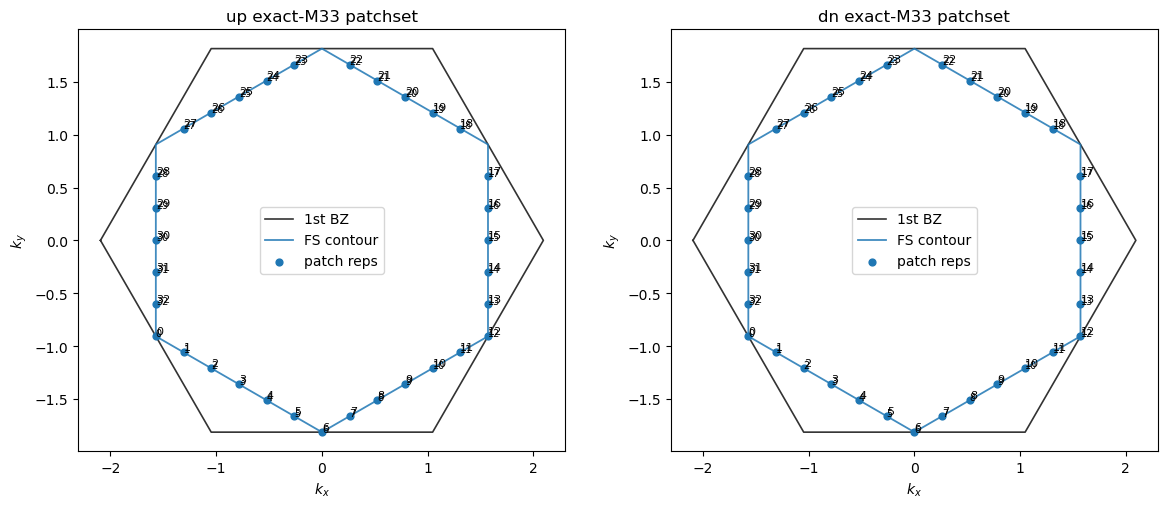

In [10]:
# ============================================================
# Manual exact-M patchsets on standard centered 1BZ hexagon
# with:
#   (1) optional duplicated-M removal modulo G
#   (2) explicit gauge fixing of Bloch states
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from patching import PatchPoint, PatchSet, plot_patchset

model = KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)

# ------------------------------------------------------------
# basic helpers
# ------------------------------------------------------------
def _sector_eig(model, k_cart, orbital_slice, band_index):
    kx, ky = float(k_cart[0]), float(k_cart[1])
    H = np.asarray(model.Hk(kx, ky), dtype=complex)
    Hs = H[orbital_slice, orbital_slice]
    evals, evecs = np.linalg.eigh(Hs)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    u = u / np.linalg.norm(u)
    return float(evals[band_index]), u

def _orbital_weight(u):
    w = np.abs(np.asarray(u, dtype=complex))**2
    return w / np.sum(w)

def _cart_to_red(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    return np.linalg.solve(B, np.asarray(k, dtype=float))

def _finite_diff_velocity(model, k_cart, orbital_slice, band_index, h=1e-6):
    kx, ky = float(k_cart[0]), float(k_cart[1])

    def band_energy(x, y):
        H = np.asarray(model.Hk(x, y), dtype=complex)
        Hs = H[orbital_slice, orbital_slice]
        evals, _ = np.linalg.eigh(Hs)
        return float(evals[band_index])

    vx = (band_energy(kx + h, ky) - band_energy(kx - h, ky)) / (2*h)
    vy = (band_energy(kx, ky + h) - band_energy(kx, ky - h)) / (2*h)
    return np.array([vx, vy], dtype=float)

# ------------------------------------------------------------
# reciprocal helpers
# ------------------------------------------------------------
def _wrap_unit_interval(x, tol=1e-12):
    x = np.asarray(x, dtype=float)
    x = x - np.floor(x)
    x[np.isclose(x, 1.0, atol=tol)] = 0.0
    x[np.isclose(x, 0.0, atol=tol)] = 0.0
    return x

def _canonicalize_k_mod_G(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    uv = np.linalg.solve(B, np.asarray(k, dtype=float))
    uv = _wrap_unit_interval(uv)
    k_can = B @ uv
    k_can[np.isclose(k_can, 0.0, atol=1e-12)] = 0.0
    return k_can

# ------------------------------------------------------------
# 1BZ geometry
# ------------------------------------------------------------
def hex_bz_vertices(model):
    """
    Standard centered 1BZ hexagon vertices for triangular/kagome reciprocal lattice.

    For reciprocal vectors b1, b2, the Wigner-Seitz 1BZ vertices are:
        ±(2b1-b2)/3, ±(b1+b2)/3, ±(-b1+2b2)/3
    """
    b1 = np.asarray(model.b1, dtype=float)
    b2 = np.asarray(model.b2, dtype=float)

    verts = np.array([
        (2*b1 - b2) / 3.0,
        (b1 + b2) / 3.0,
        (-b1 + 2*b2) / 3.0,
        -(2*b1 - b2) / 3.0,
        -(b1 + b2) / 3.0,
        -(-b1 + 2*b2) / 3.0,
    ], dtype=float)

    ang = np.arctan2(verts[:, 1], verts[:, 0])
    order = np.argsort(ang)
    return verts[order]

def exact_M6_points_1bz(model):
    """
    6 geometric M points on the boundary of the standard centered 1BZ hexagon.
    Each M point is the midpoint of one hexagon edge.
    """
    V = hex_bz_vertices(model)
    M = []

    n = len(V)
    for i in range(n):
        v0 = V[i]
        v1 = V[(i + 1) % n]
        M.append(0.5 * (v0 + v1))

    M = np.asarray(M, dtype=float)

    ang = np.arctan2(M[:, 1], M[:, 0])
    order = np.argsort(ang)
    return M[order]

def exact_M_hex_loop_points(model, points_per_edge=1):
    """
    Build a manual hex loop from the 6 exact M points on the centered 1BZ.

    points_per_edge = 1  ->  6 patches  (6 exact M points)
    points_per_edge = 2  -> 12 patches
    points_per_edge = 4  -> 24 patches

    Total patch number = 6 * points_per_edge
    """
    if points_per_edge < 1:
        raise ValueError("points_per_edge must be >= 1")

    M6 = exact_M6_points_1bz(model)
    pts = []

    n = len(M6)
    for i in range(n):
        k0 = M6[i]
        k1 = M6[(i + 1) % n]

        # t = 0, 1/p, ..., (p-1)/p ; exclude t=1 to avoid explicit duplication
        for m in range(points_per_edge):
            t = m / points_per_edge
            k = (1.0 - t) * k0 + t * k1
            pts.append(k)

    return np.asarray(pts, dtype=float)

def _hex_bz_vertices_for_plot(model):
    return hex_bz_vertices(model)

# ------------------------------------------------------------
# duplicated-M removal (patch reps only)
# ------------------------------------------------------------
def _patch_keep_indices_remove_duplicate_M_anchors(model, points_per_edge, tol=1e-10):
    """
    Return indices to KEEP among the standard exact-M loop points.

    Only the 6 anchor points are checked for modulo-G duplication:
        0, p, 2p, 3p, 4p, 5p
    where p = points_per_edge.

    All non-anchor points are always kept.
    """
    p = int(points_per_edge)
    n_full = 6 * p
    keep = np.ones(n_full, dtype=bool)

    anchor_ids = [i * p for i in range(6)]
    M6 = exact_M6_points_1bz(model)

    seen_classes = []
    for local_anchor_idx, global_idx in enumerate(anchor_ids):
        k = M6[local_anchor_idx]
        k_can = _canonicalize_k_mod_G(model, k)

        duplicated = False
        for q_can in seen_classes:
            if np.linalg.norm(k_can - q_can) < tol:
                duplicated = True
                break

        if duplicated:
            keep[global_idx] = False
        else:
            seen_classes.append(k_can)

    return np.flatnonzero(keep)

# ------------------------------------------------------------
# gauge fixing
# ------------------------------------------------------------
def _normalize_eigvec(u):
    u = np.asarray(u, dtype=complex)
    nrm = np.linalg.norm(u)
    if nrm == 0:
        raise ValueError("Encountered zero-norm eigenvector.")
    return u / nrm

def _anchor_phase(u, method="max_component"):
    u = _normalize_eigvec(u)
    if method == "max_component":
        idx = int(np.argmax(np.abs(u)))
        if np.abs(u[idx]) > 0:
            u = u * np.exp(-1j * np.angle(u[idx]))
    elif method == "first_component":
        if np.abs(u[0]) > 0:
            u = u * np.exp(-1j * np.angle(u[0]))
    else:
        raise ValueError("method must be 'max_component' or 'first_component'")
    return u

def smooth_patch_eigvecs(eigvecs, *, close_loop=True, anchor_method="max_component"):
    """
    Parallel-transport gauge fixing along the kept patch loop.

    1. Anchor first vector phase.
    2. For each next patch, rotate so <u_i | u_{i+1}> is real positive.
    3. Optionally distribute the final loop mismatch around the loop.

    Returns
    -------
    U_fixed : ndarray, shape (Npatch, Norb)
    loop_phase : float
        phase mismatch of the final overlap before loop closure correction.
    """
    U = np.asarray(eigvecs, dtype=complex).copy()
    if U.ndim != 2:
        raise ValueError("eigvecs must have shape (Npatch, Norb).")

    N = U.shape[0]
    if N == 0:
        return U, 0.0

    U[0] = _anchor_phase(U[0], method=anchor_method)

    for p in range(1, N):
        U[p] = _normalize_eigvec(U[p])
        ov = np.vdot(U[p - 1], U[p])
        if np.abs(ov) > 1e-14:
            U[p] *= np.exp(-1j * np.angle(ov))
        else:
            U[p] = _anchor_phase(U[p], method=anchor_method)

    loop_phase = 0.0
    if N > 1:
        ov_last = np.vdot(U[-1], U[0])
        if np.abs(ov_last) > 1e-14:
            loop_phase = float(np.angle(ov_last))

    if close_loop and N > 1 and np.abs(loop_phase) > 1e-14:
        # distribute mismatch smoothly along the loop
        for p in range(N):
            U[p] *= np.exp(1j * (p / N) * loop_phase)

        # re-anchor first patch and re-parallel-transport to keep neighboring overlaps smooth
        U[0] = _anchor_phase(U[0], method=anchor_method)
        for p in range(1, N):
            ov = np.vdot(U[p - 1], U[p])
            if np.abs(ov) > 1e-14:
                U[p] *= np.exp(-1j * np.angle(ov))

    for p in range(N):
        U[p] = _normalize_eigvec(U[p])

    return U, loop_phase

# ------------------------------------------------------------
# patchset builder
# ------------------------------------------------------------
def build_exactM_patchset(
    model,
    orbital_slice,
    band_index,
    *,
    points_per_edge=1,
    remove_duplicate_M_modG=False,
    gauge_fix=True,
    close_loop_gauge=True,
    gauge_anchor="max_component",
):
    # 1) full standard loop
    K_full = exact_M_hex_loop_points(model, points_per_edge=points_per_edge)

    # 2) patch reps may be reduced; contour stays full
    if remove_duplicate_M_modG:
        keep_idx = _patch_keep_indices_remove_duplicate_M_anchors(
            model,
            points_per_edge=points_per_edge,
        )
        K_patch = K_full[keep_idx]
    else:
        keep_idx = np.arange(len(K_full))
        K_patch = K_full

    bz_vertices = _hex_bz_vertices_for_plot(model)

    # 3) raw eigvecs / energies / velocities on kept patch reps
    raw_eigvecs = []
    energies = []
    velocities = []

    for k in K_patch:
        e, u = _sector_eig(model, k, orbital_slice, band_index)
        vF = _finite_diff_velocity(model, k, orbital_slice, band_index)

        raw_eigvecs.append(u)
        energies.append(e)
        velocities.append(vF)

    raw_eigvecs = np.asarray(raw_eigvecs, dtype=complex)

    # 4) explicit gauge fixing on kept patch loop
    if gauge_fix:
        fixed_eigvecs, loop_phase = smooth_patch_eigvecs(
            raw_eigvecs,
            close_loop=close_loop_gauge,
            anchor_method=gauge_anchor,
        )
        gauge_method = "manual_exact_M_hex_parallel_transport"
    else:
        fixed_eigvecs = np.asarray([_normalize_eigvec(u) for u in raw_eigvecs], dtype=complex)
        loop_phase = 0.0
        gauge_method = "manual_exact_M_hex_raw"

    # 5) PatchPoint
    patches = []
    for pid, (k, e, vF, u) in enumerate(zip(K_patch, energies, velocities, fixed_eigvecs)):
        patches.append(
            PatchPoint(
                patch_id=pid,
                k_cart=np.asarray(k, dtype=float),
                k_red=_cart_to_red(model, k),
                energy=e,
                vF=vF,
                vF_norm=float(np.linalg.norm(vF)),
                eigvec=u,
                orbital_weight=_orbital_weight(u),
            )
        )

    npatch = len(K_patch)
    suffix_dup = "_dropDupM" if remove_duplicate_M_modG else ""
    suffix_g = "_gaugeFixed" if gauge_fix else "_rawGauge"

    return PatchSet(
        mu=0.0,
        mu_used_for_contour=0.0,
        band_index=int(band_index),
        filling=np.nan,
        patches=patches,
        fs_contour_k=np.asarray(K_full, dtype=float),   # keep original full contour
        bz_vertices=np.asarray(bz_vertices, dtype=float),
        b1=np.asarray(model.b1, dtype=float),
        b2=np.asarray(model.b2, dtype=float),
        gauge_method=f"{gauge_method}_{npatch}{suffix_dup}{suffix_g}",
        gauge_loop_phase=float(loop_phase),
    )

# ------------------------------------------------------------
# choose patch density / options here
# ------------------------------------------------------------
POINTS_PER_EDGE = 6            # 1->6, 2->12, 4->24
REMOVE_DUPLICATE_M_MODG = True # True: remove replicated M anchors modulo G
GAUGE_FIX = True
CLOSE_LOOP_GAUGE = True
GAUGE_ANCHOR = "max_component"  # or "first_component"

patchsets = {
    "up": build_exactM_patchset(
        model,
        UP_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
    ),
    "dn": build_exactM_patchset(
        model,
        DN_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
    ),
}

NPATCH = patchsets["up"].Npatch
PATCHSETS = patchsets

# ------------------------------------------------------------
# print info
# ------------------------------------------------------------
print("Patch counts:", {k: v.Npatch for k, v in patchsets.items()})
print("mu used for contour (up/dn):", patchsets["up"].mu_used_for_contour, patchsets["dn"].mu_used_for_contour)
print("gauge method (up/dn):", patchsets["up"].gauge_method, patchsets["dn"].gauge_method)
print("gauge loop phase (up/dn):", patchsets["up"].gauge_loop_phase, patchsets["dn"].gauge_loop_phase)

print("\n===== exact M6 anchors in centered 1BZ =====")
M6 = exact_M6_points_1bz(model)
for i, k in enumerate(M6):
    print(
        f"M{i}: k={np.round(k, 6)} | "
        f"k_can={np.round(_canonicalize_k_mod_G(model, k), 6)}"
    )

if REMOVE_DUPLICATE_M_MODG:
    keep_idx = _patch_keep_indices_remove_duplicate_M_anchors(model, POINTS_PER_EDGE)
    print("\n===== kept indices in full loop =====")
    print(keep_idx.tolist())

for spin in ["up", "dn"]:
    print(f"\n===== {spin} exact-M{NPATCH} patches =====")
    for p in patchsets[spin].patches:
        print(
            f"id={p.patch_id:2d} | "
            f"k={np.round(p.k_cart, 6)} | "
            f"k_can={np.round(_canonicalize_k_mod_G(model, p.k_cart), 6)} | "
            f"E={p.energy:.10e} | "
            f"|vF|={p.vF_norm:.6e} | "
            f"w={np.round(p.orbital_weight, 6)}"
        )

# ------------------------------------------------------------
# neighbor distance sanity check (patch reps only)
# ------------------------------------------------------------
for spin in ["up", "dn"]:
    ks = np.array([p.k_cart for p in patchsets[spin].patches], dtype=float)
    d = np.linalg.norm(np.roll(ks, -1, axis=0) - ks, axis=1)
    print(f"\n===== {spin} neighbor distances (patch reps only) =====")
    print(np.round(d, 8))

# ------------------------------------------------------------
# optional overlap sanity check for gauge smoothness
# ------------------------------------------------------------
for spin in ["up", "dn"]:
    U = np.array([p.eigvec for p in patchsets[spin].patches], dtype=complex)
    ovs = []
    for i in range(len(U)):
        j = (i + 1) % len(U)
        ovs.append(np.vdot(U[i], U[j]))
    ovs = np.asarray(ovs, dtype=complex)

    print(f"\n===== {spin} neighbor overlaps after gauge fixing =====")
    print("abs  =", np.round(np.abs(ovs), 8))
    print("arg  =", np.round(np.angle(ovs), 8))

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, spin in zip(axes, ["up", "dn"]):
    plot_patchset(
        patchsets[spin],
        ax=ax,
        show_contour=True,   # contour remains the original full loop
        show_velocity=False,
        show_bz=True,
    )

    ks = np.array([p.k_cart for p in patchsets[spin].patches], dtype=float)
    for i, k in enumerate(ks):
        ax.text(k[0], k[1], str(i), fontsize=8, ha="left", va="bottom")

    ax.set_title(f"{spin} exact-M{NPATCH} patchset")

plt.tight_layout()
plt.show()

## 3. Helpers for running a benchmark interaction point  Debug FRG Solver

In [12]:
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt

from frg_flow import FRGFlowSolver
from interaction import BareExtendedHubbard
from frg_flow import BareVertexFromInteraction
from channels import FullVertexChannelBuilder

# --------------------------------------------------
# Optional debug wrapper
# --------------------------------------------------
_old_step = FRGFlowSolver.step
_old_run = FRGFlowSolver.run

def _debug_step(self, T_old, dT):
    print(f"[DEBUG] entering step: T_old={T_old:.8f}, dT={dT:.8e}")
    try:
        rec = _old_step(self, T_old, dT)
        print(
            f"[DEBUG] leaving step: "
            f"T_new={getattr(rec, 'temperature', float(T_old + dT)):.8f}, "
            f"rhs_norm={getattr(rec, 'rhs_norm', None)}, "
            f"channel_norm={getattr(rec, 'channel_norm', None)}, "
            f"accepted_substeps={getattr(rec, 'accepted_substeps', None)}, "
            f"max_rel_update={getattr(rec, 'max_rel_update', None)}, "
            f"terminated_early={getattr(rec, 'terminated_early', None)}"
        )
        return rec
    except Exception:
        print("[DEBUG] exception in step:")
        print(f"        T_old = {T_old:.8f}")
        print(f"        dT    = {dT:.8e}")
        print(f"        T_new = {T_old + dT:.8f}")
        raise

def _debug_run(self):
    return _old_run(self)

FRGFlowSolver.step = _debug_step
FRGFlowSolver.run = _debug_run


# --------------------------------------------------
# Build solver
# --------------------------------------------------
def build_solver(model, patchsets, U, V, flow_kwargs=None):
    flow_kwargs = {} if flow_kwargs is None else dict(flow_kwargs)

    interaction = BareExtendedHubbard.from_kagome_model(model, U=U, V=V)
    bare_gamma = BareVertexFromInteraction(interaction, patchsets)

    solver = FRGFlowSolver(
        patchsets=patchsets,
        bare_gamma=bare_gamma,
        **flow_kwargs,
    )
    return interaction, bare_gamma, solver


# --------------------------------------------------
# History utilities adapted to current FlowStepRecord
# --------------------------------------------------
def summarize_history(history):
    rows = []
    for rec in history:
        rows.append({
            "step": rec.step_index,
            "T": rec.temperature,
            "dT": rec.dT,
            "channel_norm": rec.channel_norm,
            "rhs_norm": rec.rhs_norm,
            "accepted_substeps": rec.accepted_substeps,
            "max_rel_update": rec.max_rel_update,
            "instability": rec.instability,
            "instability_reason": rec.instability_reason,
            "terminated_early": rec.terminated_early,
            "termination_reason": rec.termination_reason,
            "diagnosis_payload": rec.diagnosis_payload,
        })
    return rows


def pretty_print_final_record(history):
    rec = history[-1]
    print("===== Final record =====")
    pprint(rec.summary_dict())
    return rec


def plot_history(history, title):
    steps = [h.step_index for h in history]
    Ts = [h.temperature for h in history]
    norms = [h.channel_norm for h in history]
    rhs = [h.rhs_norm for h in history]
    substeps = [h.accepted_substeps for h in history]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(steps, norms, marker="o")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("channel norm")
    axes[0].set_title(f"{title}: channel norm")

    axes[1].plot(steps, rhs, marker="o")
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("rhs norm")
    axes[1].set_title(f"{title}: rhs norm")

    axes[2].plot(steps, substeps, marker="o")
    axes[2].set_xlabel("step")
    axes[2].set_ylabel("accepted substeps")
    axes[2].set_title(f"{title}: adaptive stepping")

    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# Mother-kernel builder for the new API
# --------------------------------------------------
def make_channel_builder(solver):
    return FullVertexChannelBuilder(
        gamma=solver.current_gamma_accessor(),
        patchsets=solver.patchsets,
        closure_map=solver.closure_map(),
        transfer_context=solver.transfer_context(),
        q_merge_tol_red=solver.q_merge_tol_red,
        q_key_decimals=solver.q_key_decimals,
    )


# --------------------------------------------------
# Main runner
# --------------------------------------------------
def run_case(case_name, U, V, flow_kwargs=None):
    print(f"\n===== Running case: {case_name} (U={U}, V={V}) =====")

    interaction, bare_gamma, solver = build_solver(
        model=model,
        patchsets=patchsets,
        U=U,
        V=V,
        flow_kwargs=flow_kwargs if flow_kwargs is not None else FLOW_KWARGS,
    )

    history = solver.run()

    print(f"history length = {len(history)}")
    print(
        "instability record =",
        None if solver.instability_record is None else solver.instability_record.step_index
    )

    final_rec = pretty_print_final_record(history)
    plot_history(history, case_name)

    return {
        "case_name": case_name,
        "U": U,
        "V": V,
        "interaction": interaction,
        "solver": solver,
        "history": history,
        "final_record": final_rec,
    }


## 4. FM benchmark: `U=6, V=0`

Expectation from the PRL benchmark at van Hove filling:
- dominant onsite interaction should favor **ferromagnetism (FM)**.



===== Running case: FM benchmark (U=6.0, V=0.0) =====
[DEBUG] entering step: T_old=50.00000000, dT=-1.91673796e-01
[DEBUG] leaving step: T_new=49.80832620, rhs_norm=0.04577765266555675, channel_norm=6.0, accepted_substeps=1, max_rel_update=0.0014623960773308192, terminated_early=False
[DEBUG] entering step: T_old=49.80832620, dT=-1.90939019e-01
[DEBUG] leaving step: T_new=49.61738718, rhs_norm=0.04626970153285951, channel_norm=6.000080201618989, accepted_substeps=1, max_rel_update=0.0014724485718694282, terminated_early=False
[DEBUG] entering step: T_old=49.61738718, dT=-1.90207059e-01
[DEBUG] leaving step: T_new=49.42718013, rhs_norm=0.046768092175373796, channel_norm=6.0002416061591255, accepted_substeps=1, max_rel_update=0.0014825837278529099, terminated_early=False
[DEBUG] entering step: T_old=49.42718013, dT=-1.89477905e-01
[DEBUG] leaving step: T_new=49.23770222, rhs_norm=0.0472729253365058, channel_norm=6.0004852289782695, accepted_substeps=1, max_rel_update=0.00149280236370509

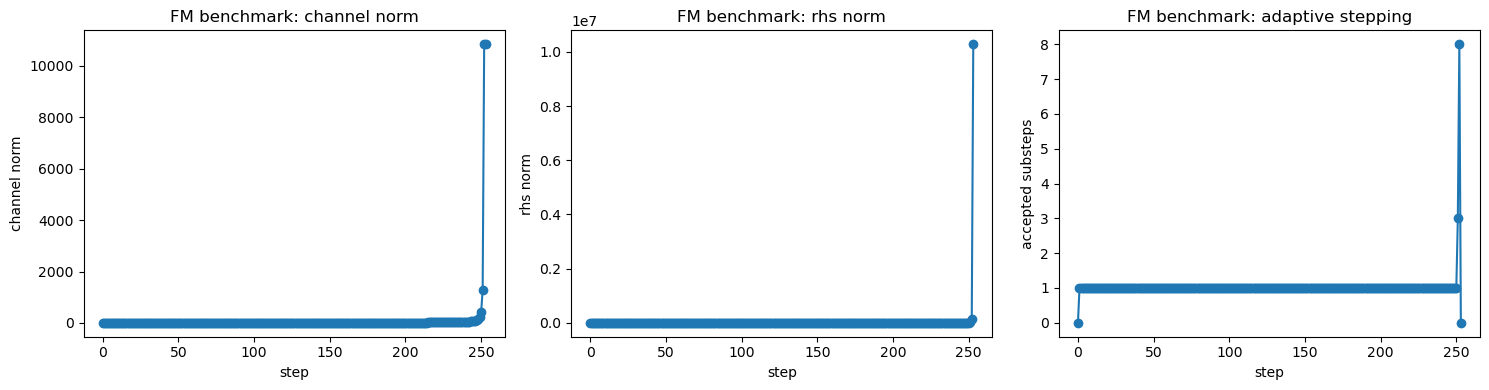

In [15]:

fm_result = run_case("FM benchmark", U=6.0, V=.0, flow_kwargs=FLOW_KWARGS)


===== Final-state mother-channel diagnosis across all Q =====

===== Q[0] = [0. 0.] =====
pp_mother_sz0            |eig|max = 26712.317
ph_mother_longitudinal   |eig|max = 697361.75
--> leading mother channel at this Q: ph_mother_longitudinal  (|eig|max = 697361.75)

===== Q[1] = [0.         1.81379936] =====
pp_mother_sz0            |eig|max = 21552.32
ph_mother_longitudinal   |eig|max = 10780.128
--> leading mother channel at this Q: pp_mother_sz0  (|eig|max = 21552.32)

===== Q[2] = [1.57079633 0.90689968] =====
pp_mother_sz0            |eig|max = 21583.663
ph_mother_longitudinal   |eig|max = 10780.128
--> leading mother channel at this Q: pp_mother_sz0  (|eig|max = 21583.663)

===== Q[3] = [-1.57079633  0.90689968] =====
pp_mother_sz0            |eig|max = 21552.32
ph_mother_longitudinal   |eig|max = 10780.128
--> leading mother channel at this Q: pp_mother_sz0  (|eig|max = 21552.32)
[{'Q_index': 0, 'Q_vec': array([0., 0.]), 'pp_mother_sz0': 26712.31735799711, 'ph_mother_longitudin

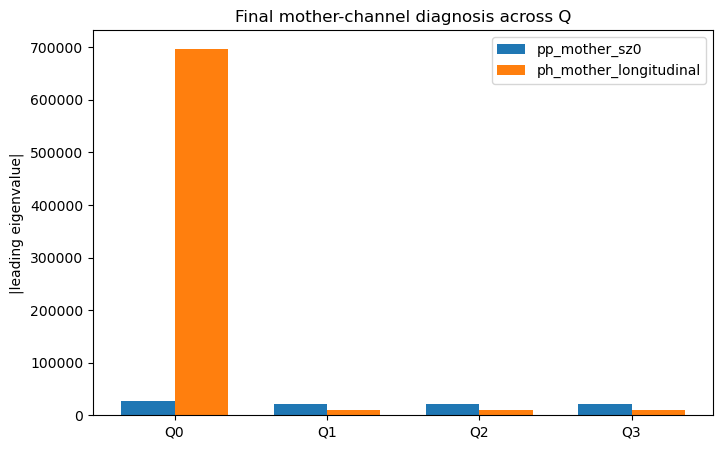


==== pp_mother_sz0 ====
Q = [0. 0.]
first |eig|max = 26712.31735799711
vec.real = [-0.10989081  0.12193991  0.12660284  0.12449938  0.12660284  0.12193991
 -0.10989081  0.12193991  0.12660284  0.12449938  0.12660284  0.12193991
 -0.10989081  0.12193991  0.12660284  0.12449938  0.12660284  0.12193991
  0.12193991  0.12660284  0.12449938  0.12660284  0.12193991  0.12193991
  0.12660284  0.12449938  0.12660284  0.12193991  0.12193991  0.12660284
  0.12449938  0.12660284  0.12193991  0.10989081 -0.12193991 -0.12660284
 -0.12449938 -0.12660284 -0.12193991  0.10989081 -0.12193991 -0.12660284
 -0.12449938 -0.12660284 -0.12193991  0.10989081 -0.12193991 -0.12660284
 -0.12449938 -0.12660284 -0.12193991 -0.12193991 -0.12660284 -0.12449938
 -0.12660284 -0.12193991 -0.12193991 -0.12660284 -0.12449938 -0.12660284
 -0.12193991 -0.12193991 -0.12660284 -0.12449938 -0.12660284 -0.12193991]
vec.abs  = [0.10989081 0.12193991 0.12660284 0.12449938 0.12660284 0.12193991
 0.10989081 0.12193991 0.12660284 0

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from channels import FullVertexChannelBuilder

# ----------------------------------------
# Choose Q list
# ----------------------------------------
Qs_to_check = DIAGNOSIS_QS

# If you want to test Q -> Q+G invariance, do it manually like this:
# shift = 5*np.array([np.pi, np.pi/np.sqrt(3)]) + np.array([0, 2*np.pi/np.sqrt(3)])
# Qs_to_check = [np.asarray(Q, dtype=float) + shift for Q in DIAGNOSIS_QS]

solver = fm_result["solver"]

# Build the diagnosis object from the CURRENT full vertex
builder = FullVertexChannelBuilder(
    gamma=solver.current_gamma_accessor(),
    patchsets=solver.patchsets,
    closure_map=solver.closure_map(),
    transfer_context=solver.transfer_context(),
    q_merge_tol_red=solver.q_merge_tol_red,
    q_key_decimals=solver.q_key_decimals,
)

mother_channels = [
    "pp_mother_sz0",
    "ph_mother_longitudinal",
]

print("===== Final-state mother-channel diagnosis across all Q =====")
Q_summary = []

for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    mothers = builder.build_mother_kernel_dict(Q)

    print(f"\n===== Q[{i}] = {Q} =====")
    row = {
        "Q_index": i,
        "Q_vec": Q,
    }

    vals_dict = {}
    for name in mother_channels:
        k = mothers[name]
        vals, vecs = k.eig(sort_by="abs")
        eigmax = abs(vals[0])
        vals_dict[name] = eigmax
        row[name] = float(eigmax)
        print(f"{name:24s} |eig|max = {eigmax:.8g}")

    lead_name = max(vals_dict, key=vals_dict.get)
    row["leading_geometry"] = lead_name
    row["leading_value"] = vals_dict[lead_name]
    Q_summary.append(row)

    print(f"--> leading mother channel at this Q: {lead_name}  (|eig|max = {vals_dict[lead_name]:.8g})")

print(Q_summary)

labels = [f"Q{i}" for i in range(len(Q_summary))]
x = np.arange(len(labels))
width = 0.35

pp_vals = [row["pp_mother_sz0"] for row in Q_summary]
ph_vals = [row["ph_mother_longitudinal"] for row in Q_summary]

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, pp_vals, width, label="pp_mother_sz0")
plt.bar(x + width/2, ph_vals, width, label="ph_mother_longitudinal")

plt.xticks(x, labels)
plt.ylabel("|leading eigenvalue|")
plt.title("Final mother-channel diagnosis across Q")
plt.legend()
plt.show()

# ----------------------------------------
# Detailed printout at Q = 0
# ----------------------------------------
Q = np.array([0.0, 0.0], dtype=float)
mothers = builder.build_mother_kernel_dict(Q)

for name in ["pp_mother_sz0", "ph_mother_longitudinal"]:
    k = mothers[name]
    vals, vecs = k.eig(sort_by="abs")

    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("first |eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))

    if len(vals) > 1:
        print(f"\n==== {name} ====")
        print("Q =", k.Q)
        print("second |eig|max =", abs(vals[1]))
        print("vec.real =", np.real(vecs[:, 1]))
        print("vec.abs  =", np.abs(vecs[:, 1]))


## 5. sBO benchmark: `U=6, V=6`

<!-- - dominant nearest-neighbor repulsion should favor **Pomeranchuk instability (PI)** with d-wave character. -->


[DEBUG] entering step: T_old=50.00000000, dT=-1.91673796e-01
[DEBUG] leaving step: T_new=49.80832620, rhs_norm=0.3136185934091213, channel_norm=6.04067897816036, accepted_substeps=1, max_rel_update=0.010018744388887942, terminated_early=False
[DEBUG] entering step: T_old=49.80832620, dT=-1.90939019e-01
[DEBUG] leaving step: T_new=49.61738718, rhs_norm=0.3207232936052355, channel_norm=6.082420545299427, accepted_substeps=1, max_rel_update=0.010137699975423882, terminated_early=False
[DEBUG] entering step: T_old=49.61738718, dT=-1.90207059e-01
[DEBUG] leaving step: T_new=49.42718013, rhs_norm=0.3280925134907931, channel_norm=6.125264739756782, accepted_substeps=1, max_rel_update=0.010259979828984992, terminated_early=False
[DEBUG] entering step: T_old=49.42718013, dT=-1.89477905e-01
[DEBUG] leaving step: T_new=49.23770222, rhs_norm=0.3357494106150425, channel_norm=6.169253606636033, accepted_substeps=1, max_rel_update=0.010386015561173, terminated_early=False
[DEBUG] entering step: T_old

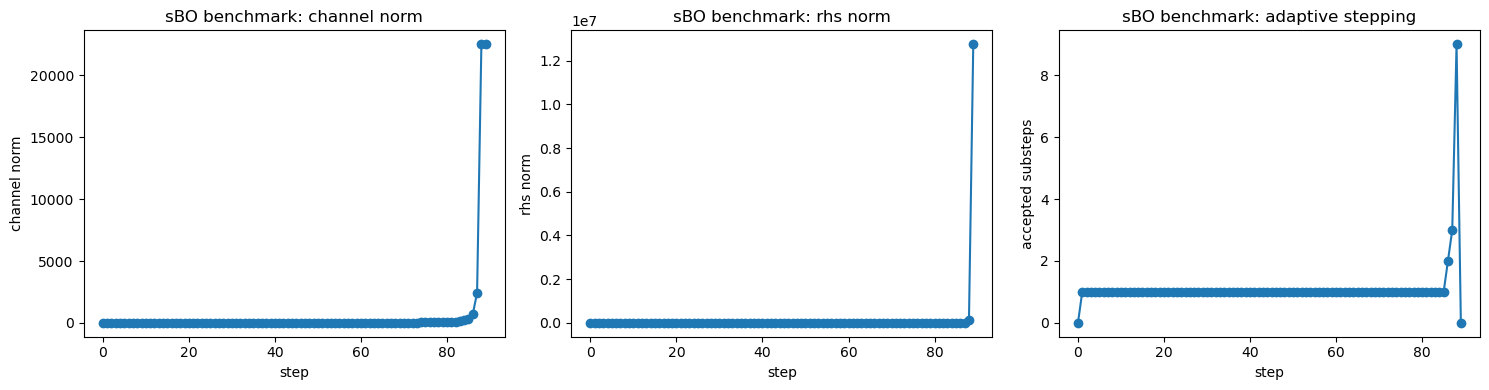

In [20]:

sBO_result = run_case("sBO benchmark", U=1.0, V=3.0, flow_kwargs=FLOW_KWARGS)


===== Final-state mother-channel diagnosis across all Q =====

===== Q[0] = [0. 0.] =====
pp_mother_sz0            |eig|max = 45041.201
ph_mother_longitudinal   |eig|max = 1462214.7
--> leading mother channel at this Q: ph_mother_longitudinal  (|eig|max = 1462214.7)

===== Q[1] = [0.         1.81379936] =====
pp_mother_sz0            |eig|max = 45062.934
ph_mother_longitudinal   |eig|max = 22364.476
--> leading mother channel at this Q: pp_mother_sz0  (|eig|max = 45062.934)

===== Q[2] = [1.57079633 0.90689968] =====
pp_mother_sz0            |eig|max = 45066.153
ph_mother_longitudinal   |eig|max = 22364.522
--> leading mother channel at this Q: pp_mother_sz0  (|eig|max = 45066.153)

===== Q[3] = [-1.57079633  0.90689968] =====
pp_mother_sz0            |eig|max = 45065.649
ph_mother_longitudinal   |eig|max = 22364.522
--> leading mother channel at this Q: pp_mother_sz0  (|eig|max = 45065.649)
[{'Q_index': 0, 'Q_vec': array([0., 0.]), 'pp_mother_sz0': 45041.20091617002, 'ph_mother_longit

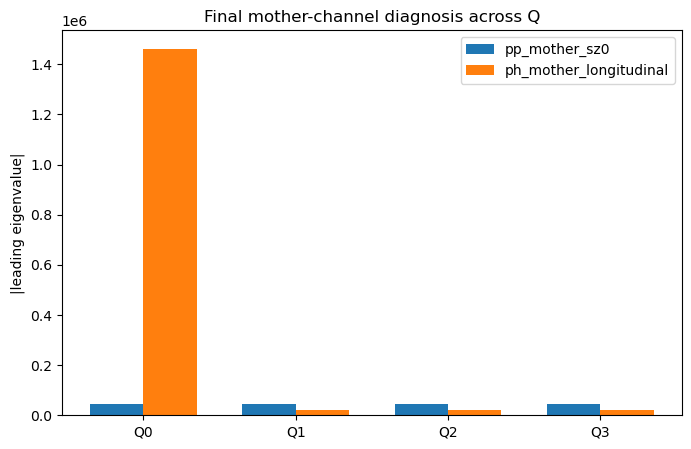


==== pp_mother_sz0 ====
Q = [0. 0.]
first |eig|max = 45041.20091617002
vec.real = [-4.18385532e-15 -1.01202867e-01 -2.26596994e-01 -1.71809197e-02
 -2.28470234e-01 -1.04424137e-01  7.66047501e-15 -1.04424137e-01
 -2.28470234e-01 -1.71809197e-02 -2.26596994e-01 -1.01202867e-01
  1.09317503e-14 -3.18731642e-03 -1.84147196e-03  1.08212582e-11
  1.84147225e-03  3.18731654e-03  1.01202867e-01  2.26596994e-01
  1.71809197e-02  2.28470234e-01  1.04424137e-01  1.04424137e-01
  2.28470234e-01  1.71809197e-02  2.26596994e-01  1.01202867e-01
  3.18731642e-03  1.84147196e-03 -1.07855505e-11 -1.84147225e-03
 -3.18731654e-03  4.05483533e-15 -1.01202867e-01 -2.26596994e-01
 -1.71809197e-02 -2.28470234e-01 -1.04424137e-01 -7.53087907e-15
 -1.04424137e-01 -2.28470234e-01 -1.71809197e-02 -2.26596994e-01
 -1.01202867e-01 -1.07468369e-14 -3.18731642e-03 -1.84147196e-03
  1.07855505e-11  1.84147225e-03  3.18731654e-03  1.01202867e-01
  2.26596994e-01  1.71809197e-02  2.28470234e-01  1.04424137e-01
  1.044

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from channels import FullVertexChannelBuilder

# ----------------------------------------
# Choose Q list
# ----------------------------------------
Qs_to_check = DIAGNOSIS_QS

# If you want to test Q -> Q+G invariance, do it manually like this:
# shift = 5*np.array([np.pi, np.pi/np.sqrt(3)]) + np.array([0, 2*np.pi/np.sqrt(3)])
# Qs_to_check = [np.asarray(Q, dtype=float) + shift for Q in DIAGNOSIS_QS]

solver = sBO_result["solver"]

# Build the diagnosis object from the CURRENT full vertex
builder = FullVertexChannelBuilder(
    gamma=solver.current_gamma_accessor(),
    patchsets=solver.patchsets,
    closure_map=solver.closure_map(),
    transfer_context=solver.transfer_context(),
    q_merge_tol_red=solver.q_merge_tol_red,
    q_key_decimals=solver.q_key_decimals,
)

mother_channels = [
    "pp_mother_sz0",
    "ph_mother_longitudinal",
]

print("===== Final-state mother-channel diagnosis across all Q =====")
Q_summary = []

for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    mothers = builder.build_mother_kernel_dict(Q)

    print(f"\n===== Q[{i}] = {Q} =====")
    row = {
        "Q_index": i,
        "Q_vec": Q,
    }

    vals_dict = {}
    for name in mother_channels:
        k = mothers[name]
        vals, vecs = k.eig(sort_by="abs")
        eigmax = abs(vals[0])
        vals_dict[name] = eigmax
        row[name] = float(eigmax)
        print(f"{name:24s} |eig|max = {eigmax:.8g}")

    lead_name = max(vals_dict, key=vals_dict.get)
    row["leading_geometry"] = lead_name
    row["leading_value"] = vals_dict[lead_name]
    Q_summary.append(row)

    print(f"--> leading mother channel at this Q: {lead_name}  (|eig|max = {vals_dict[lead_name]:.8g})")

print(Q_summary)

labels = [f"Q{i}" for i in range(len(Q_summary))]
x = np.arange(len(labels))
width = 0.35

pp_vals = [row["pp_mother_sz0"] for row in Q_summary]
ph_vals = [row["ph_mother_longitudinal"] for row in Q_summary]

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, pp_vals, width, label="pp_mother_sz0")
plt.bar(x + width/2, ph_vals, width, label="ph_mother_longitudinal")

plt.xticks(x, labels)
plt.ylabel("|leading eigenvalue|")
plt.title("Final mother-channel diagnosis across Q")
plt.legend()
plt.show()

# ----------------------------------------
# Detailed printout at Q = 0
# ----------------------------------------
Q = np.array([0.0, 0.0], dtype=float)
mothers = builder.build_mother_kernel_dict(Q)

for name in ["pp_mother_sz0", "ph_mother_longitudinal"]:
    k = mothers[name]
    vals, vecs = k.eig(sort_by="abs")

    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("first |eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))

    if len(vals) > 1:
        print(f"\n==== {name} ====")
        print("Q =", k.Q)
        print("second |eig|max =", abs(vals[1]))
        print("vec.real =", np.real(vecs[:, 1]))
        print("vec.abs  =", np.abs(vecs[:, 1]))

# Save & Load

In [ ]:
# ============================================================
# SAVE fm_result and sBO_result
# ============================================================

import os
import gzip

try:
    import cloudpickle as cpkl
    _PICKLER_NAME = "cloudpickle"
except Exception:
    import pickle as cpkl
    _PICKLER_NAME = "pickle"

SAVE_PATH = "saved_frg_results.pkl.gz"

payload = {
    "fm_result": fm_result,
    "sBO_result": sBO_result,
}

with gzip.open(SAVE_PATH, "wb") as f:
    cpkl.dump(payload, f)

print(f"[SAVE] done with {_PICKLER_NAME}")
print(f"[SAVE] file = {os.path.abspath(SAVE_PATH)}")
print(f"[SAVE] keys = {list(payload.keys())}")

In [7]:
# ============================================================
# LOAD fm_result and sBO_result
# ============================================================

import os
import gzip

try:
    import cloudpickle as cpkl
    _PICKLER_NAME = "cloudpickle"
except Exception:
    import pickle as cpkl
    _PICKLER_NAME = "pickle"

SAVE_PATH = "saved_frg_results.pkl.gz"

if not os.path.exists(SAVE_PATH):
    raise FileNotFoundError(f"Cannot find saved file: {os.path.abspath(SAVE_PATH)}")

with gzip.open(SAVE_PATH, "rb") as f:
    loaded_payload = cpkl.load(f)

fm_result = loaded_payload["fm_result"]
sBO_result = loaded_payload["sBO_result"]

print(f"[LOAD] loaded with {_PICKLER_NAME}")
print(f"[LOAD] keys = {list(loaded_payload.keys())}")
print(f"[LOAD] fm_result type = {type(fm_result)}")
print(f"[LOAD] sBO_result type = {type(sBO_result)}")

# ============================================================
# SANITY CHECK after load
# ============================================================

for name, obj in [("fm_result", fm_result), ("sBO_result", sBO_result)]:
    print(f"\n===== {name} =====")
    if isinstance(obj, dict):
        print("dict keys:", list(obj.keys()))
        if "solver" in obj:
            solver = obj["solver"]
            print("solver type:", type(solver))
            print("T_start, T_stop =", getattr(solver, "T_start", None), getattr(solver, "T_stop", None))
            print("diagnosis_Qs =", getattr(solver, "diagnosis_Qs", None))
    else:
        print("type:", type(obj))

[LOAD] loaded with pickle
[LOAD] keys = ['fm_result', 'sBO_result']
[LOAD] fm_result type = <class 'dict'>
[LOAD] sBO_result type = <class 'dict'>

===== fm_result =====
dict keys: ['case_name', 'U', 'V', 'interaction', 'solver', 'history', 'final_record']
solver type: <class 'frg_flow.FRGFlowSolver'>
T_start, T_stop = 30.0 0.5
diagnosis_Qs = [array([0., 0.]), array([1.57079633, 2.72069905]), array([0.        , 1.81379936]), array([1.57079633, 0.90689968])]

===== sBO_result =====
dict keys: ['case_name', 'U', 'V', 'interaction', 'solver', 'history', 'final_record']
solver type: <class 'frg_flow.FRGFlowSolver'>
T_start, T_stop = 30.0 0.5
diagnosis_Qs = [array([0., 0.]), array([1.57079633, 2.72069905]), array([0.        , 1.81379936]), array([1.57079633, 0.90689968])]


# Debug